# **Operations to be done with Google Drive**

In [1]:
#@title Linking with Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Prerequisite Operations**

In [2]:
#@title Installing Dependencies

%pip install tqdm torchvision

In [3]:
#@title Requirements

import torch
import torch.nn as nn
import torch.optim as optim
import os

In [4]:
#@title Choosing Resources

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# **Data Processing**

In [5]:
#@title Data Imports

import cv2
import imghdr
from matplotlib import pyplot as plt
from tqdm import tqdm
import numpy as np

data_dir = '/content/drive/My Drive/FinalProject/aggregated'


CLASS_NAMES = [
    'pen', 'paper', 'book', 'clock', 'phone', 'laptop',
    'chair', 'desk', 'bottle', 'keychain', 'backpack', 'calculator'
]
n_classes = len(CLASS_NAMES)

/tmp/ipykernel_10607/1150579052.py:4: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


Loaded 4543 images across 313 folders.
Loaded 4543 images across 313 folders.
Batch label vectors (multi-hot):
 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.]]


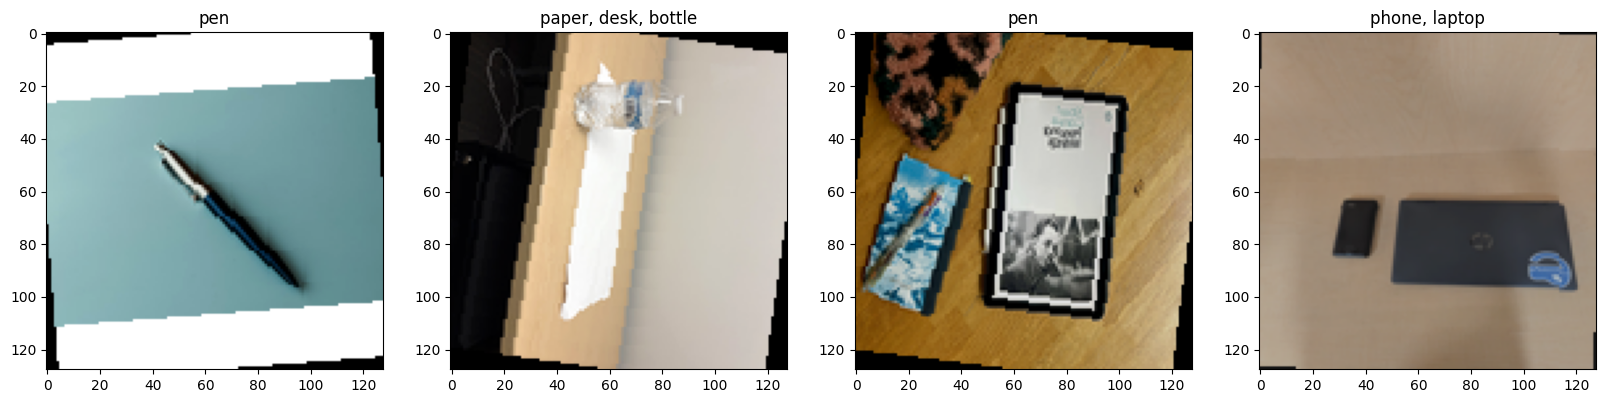

In [6]:
#@title Custom Multi-Label Dataset

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class MultiLabelImageFolder(Dataset):

    VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}

    def __init__(self, root, class_names, transform=None):
        self.root        = root
        self.class_names = class_names
        self.transform   = transform
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.samples     = self._load_samples()

    def _folder_to_multihot(self, folder_name):
        """Split folder name on '_' and fire the bit for every recognised token."""
        vec = torch.zeros(len(self.class_names), dtype=torch.float32)
        for token in folder_name.split('_'):
            if token in self.class_to_idx:
                vec[self.class_to_idx[token]] = 1.0
        return vec

    def _load_samples(self):
        samples = []
        for folder in sorted(os.listdir(self.root)):
            folder_path = os.path.join(self.root, folder)
            if not os.path.isdir(folder_path):
                continue
            label = self._folder_to_multihot(folder)
            if label.sum() == 0:
                print(f'  WARNING: folder "{folder}" matched no class names — skipping.')
                continue
            for fname in os.listdir(folder_path):
                if os.path.splitext(fname)[1].lower() in self.VALID_EXTENSIONS:
                    samples.append((os.path.join(folder_path, fname), label))
        print(f'Loaded {len(samples)} images across {len(os.listdir(self.root))} folders.')
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label



train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# full_dataset = MultiLabelImageFolder(root=data_dir, class_names=CLASS_NAMES, transform=train_transform)
full_dataset = MultiLabelImageFolder(root=data_dir, class_names=CLASS_NAMES, transform=None)

# preview_loader = DataLoader(full_dataset, batch_size=32, shuffle=True)
preview_dataset = MultiLabelImageFolder(root=data_dir, class_names=CLASS_NAMES, transform=train_transform)
preview_loader = DataLoader(preview_dataset, batch_size=32, shuffle=True)
batch_imgs, batch_labels = next(iter(preview_loader))
print('Batch label vectors (multi-hot):\n', batch_labels[:4].numpy())

fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
for idx in range(4):

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img  = (batch_imgs[idx] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax[idx].imshow(img)
    present = [CLASS_NAMES[i] for i, v in enumerate(batch_labels[idx]) if v == 1]
    ax[idx].title.set_text(', '.join(present))
plt.show()


In [7]:
#@title Preprocessing Data

# total      = len(full_dataset)
# train_size = int(total * 0.70)
# val_size   = int(total * 0.15)
# test_size  = total - train_size - val_size

# train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
#     full_dataset, [train_size, val_size, test_size]
# )

BATCH_SIZE = 16

# print(train_size, '+', val_size, '+', test_size, '=', total)
total = len(full_dataset)

train_size = int(total * 0.70)
val_size   = int(total * 0.15)
test_size  = total - train_size - val_size

train_subset, val_subset, test_subset = torch.utils.data.random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataset = MultiLabelImageFolder(root=data_dir, class_names=CLASS_NAMES, transform=train_transform)
val_dataset   = MultiLabelImageFolder(root=data_dir, class_names=CLASS_NAMES, transform=val_test_transform)
test_dataset  = MultiLabelImageFolder(root=data_dir, class_names=CLASS_NAMES, transform=val_test_transform)


train_dataset.samples = [full_dataset.samples[i] for i in train_subset.indices]
val_dataset.samples   = [full_dataset.samples[i] for i in val_subset.indices]
test_dataset.samples  = [full_dataset.samples[i] for i in test_subset.indices]

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Loaded 4543 images across 313 folders.
Loaded 4543 images across 313 folders.
Loaded 4543 images across 313 folders.


In [8]:
#@title Assigning weights to classes

label_counts = torch.zeros(n_classes)
total_train  = 0
all_train_labels = []

for _, y in tqdm(train_loader):
    label_counts  += y.sum(dim=0)
    total_train   += y.size(0)
    all_train_labels.append(y)

all_train_labels = torch.cat(all_train_labels, dim=0).numpy()

neg_counts         = total_train - label_counts
class_weights_tensor = (neg_counts / label_counts.clamp(min=1)).to(device)

for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:12s}  positives={int(label_counts[i]):5d}  pos_weight={class_weights_tensor[i].item():.3f}')

100%|██████████| 199/199 [08:33<00:00,  2.58s/it]


  pen           positives=  531  pos_weight=4.989
  paper         positives=  498  pos_weight=5.386
  book          positives=  518  pos_weight=5.139
  clock         positives=  357  pos_weight=7.908
  phone         positives=  499  pos_weight=5.373
  laptop        positives=  512  pos_weight=5.211
  chair         positives=  443  pos_weight=6.178
  desk          positives=  432  pos_weight=6.361
  bottle        positives=  510  pos_weight=5.235
  keychain      positives=  441  pos_weight=6.211
  backpack      positives=  425  pos_weight=6.482
  calculator    positives=  439  pos_weight=6.244


# **Deep Learning Models Creation, Training, Evaluating, Saving, Performance Graph etc.**

In [9]:
#@title Deep Models MobileNetV2

''' Deep Model '''
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights, resnet18, ResNet18_Weights

def create_model(num_labels):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1) # place after this if needed
    #model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    for param in model.features.parameters():
        param.requires_grad = False
    # in_features = model.fc.in_features
    # model.fc = nn.Sequential(
    in_features = model.classifier[1].in_features
    # model.classifier = nn.Sequential(
    #     nn.Dropout(p=0.5),
    #     nn.Linear(in_features, 256),
    #     nn.ReLU(),
    #     nn.Linear(256, num_labels)
    # )
    model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(256, num_labels)
  )
    return model

def mobilenetv2(n_classes):
    return create_model(n_classes)

model = mobilenetv2(n_classes).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights_tensor)

print(model)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 128MB/s]


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [10]:
#@title Training the Models

from torch.utils.tensorboard import SummaryWriter

logdir = '/content/drive/My Drive/FinalProject/logs'
writer = SummaryWriter(log_dir=logdir)

EPOCHS    = 30
THRESHOLD = 0.65

best_val_loss   = float('inf')
patience        = 5
patience_counter = 0

hist = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0.0
    correct_labels, total_labels = 0, 0

    for X, y in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]'):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss    = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss  += loss.item() * X.size(0)
        preds          = (torch.sigmoid(outputs) > THRESHOLD).float()
        correct_labels += (preds == y).sum().item()
        total_labels   += y.numel()

    train_loss = running_loss / len(train_dataset)
    train_acc  = correct_labels / total_labels


    model.eval()
    val_loss_sum = 0.0
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            outputs      = model(X)
            loss         = criterion(outputs, y)
            val_loss_sum += loss.item() * X.size(0)
            preds         = (torch.sigmoid(outputs) > THRESHOLD).float()
            val_correct  += (preds == y).sum().item()
            val_total    += y.numel()

    val_loss = val_loss_sum / len(val_dataset)
    val_acc  = val_correct / val_total

    hist['loss'].append(train_loss)
    hist['accuracy'].append(train_acc)
    hist['val_loss'].append(val_loss)
    hist['val_accuracy'].append(val_acc)

    writer.add_scalar('Loss/train',     train_loss, epoch)
    writer.add_scalar('Loss/val',       val_loss,   epoch)
    writer.add_scalar('Accuracy/train', train_acc,  epoch)
    writer.add_scalar('Accuracy/val',   val_acc,    epoch)

    print(f'Epoch {epoch+1}: loss={train_loss:.4f}, acc={train_acc:.4f}, '
          f'val_loss={val_loss:.4f}, val_acc={val_acc:.4f}')


    # if val_loss < best_val_loss - 0.001:
    #     best_val_loss    = val_loss
    #     patience_counter = 0
    # else:
    #     patience_counter += 1
    #     if patience_counter >= patience:
    #         print(f'Early stopping triggered at epoch {epoch+1}')
    #         break
    if val_loss < best_val_loss - 0.001:
      best_val_loss    = val_loss
      patience_counter = 0
    torch.save(model.state_dict(), 'best_model.pth')

writer.close()
print(hist)

Epoch 1/30 [Train]: 100%|██████████| 199/199 [00:17<00:00, 11.48it/s]


Epoch 1: loss=1.1579, acc=0.7923, val_loss=1.0225, val_acc=0.8702


Epoch 2/30 [Train]: 100%|██████████| 199/199 [00:16<00:00, 12.35it/s]


Epoch 2: loss=1.0379, acc=0.8261, val_loss=0.9506, val_acc=0.8716


Epoch 3/30 [Train]: 100%|██████████| 199/199 [00:16<00:00, 12.20it/s]


...

Epoch 28: loss=0.7876, acc=0.8560, val_loss=0.7480, val_acc=0.8846


Epoch 29/30 [Train]: 100%|██████████| 199/199 [00:15<00:00, 12.71it/s]


Epoch 29: loss=0.7878, acc=0.8582, val_loss=0.7316, val_acc=0.8918


Epoch 30/30 [Train]: 100%|██████████| 199/199 [00:16<00:00, 12.39it/s]


Epoch 30: loss=0.7849, acc=0.8604, val_loss=0.7547, val_acc=0.8846
{'loss': [1.1578692050849866, 1.0378934257435348, 0.9760747943284377, 0.9453693710033249, 0.9170795134028549, 0.899500330289205, 0.8843234233136447, 0.8730910092029931, 0.8603405016773152, 0.8414863617165284, 0.8319126147144246, 0.8322917237971563, 0.8278082103849207, 0.822546113287128, 0.8178330309735904, 0.8204541644960079, 0.8156318324167023, 0.8157833588198296, 0.8015306357317751, 0.8085406737507514, 0.7926360005852562, 0.8007335392933972, 0.7969312901766795, 0.7990254332434457, 0.7850517574346291, 0.7904669330554939, 0.7949170963569258, 0.7875831649738287, 0.7878241997844768, 0.7849404676155474], 'accuracy': [0.7922955974842767, 0.8260744234800839, 0.839832285115304, 0.8437106918238994, 0.8464098532494759, 0.8476939203354298, 0.8503930817610063, 0.8490041928721174, 0.8528825995807128, 0.8542452830188679, 0.8567085953878407, 0.8538784067085954, 0.8556341719077568, 0.8549266247379455, 0.8572327044025158, 0.8580974842

Loss: 0.787485089469865

--- Per-class report (each of the 12 labels treated as independent binary) ---
              precision    recall  f1-score   support

         pen     0.6818    0.3947    0.5000       114
       paper     0.6500    0.4771    0.5503       109
        book     0.5738    0.3684    0.4487        95
       clock     0.5811    0.5375    0.5584        80
       phone     0.4627    0.5345    0.4960       116
      laptop     0.6800    0.6476    0.6634       105
       chair     0.6354    0.7176    0.6740        85
        desk     0.5196    0.6463    0.5761        82
      bottle     0.5373    0.6154    0.5737       117
    keychain     0.4255    0.4762    0.4494        84
    backpack     0.8902    0.8022    0.8439        91
  calculator     0.6333    0.5278    0.5758       108

   micro avg     0.5939    0.5573    0.5750      1186
   macro avg     0.6059    0.5621    0.5758      1186
weighted avg     0.6065    0.5573    0.5732      1186
 samples avg     0.5934    0.6

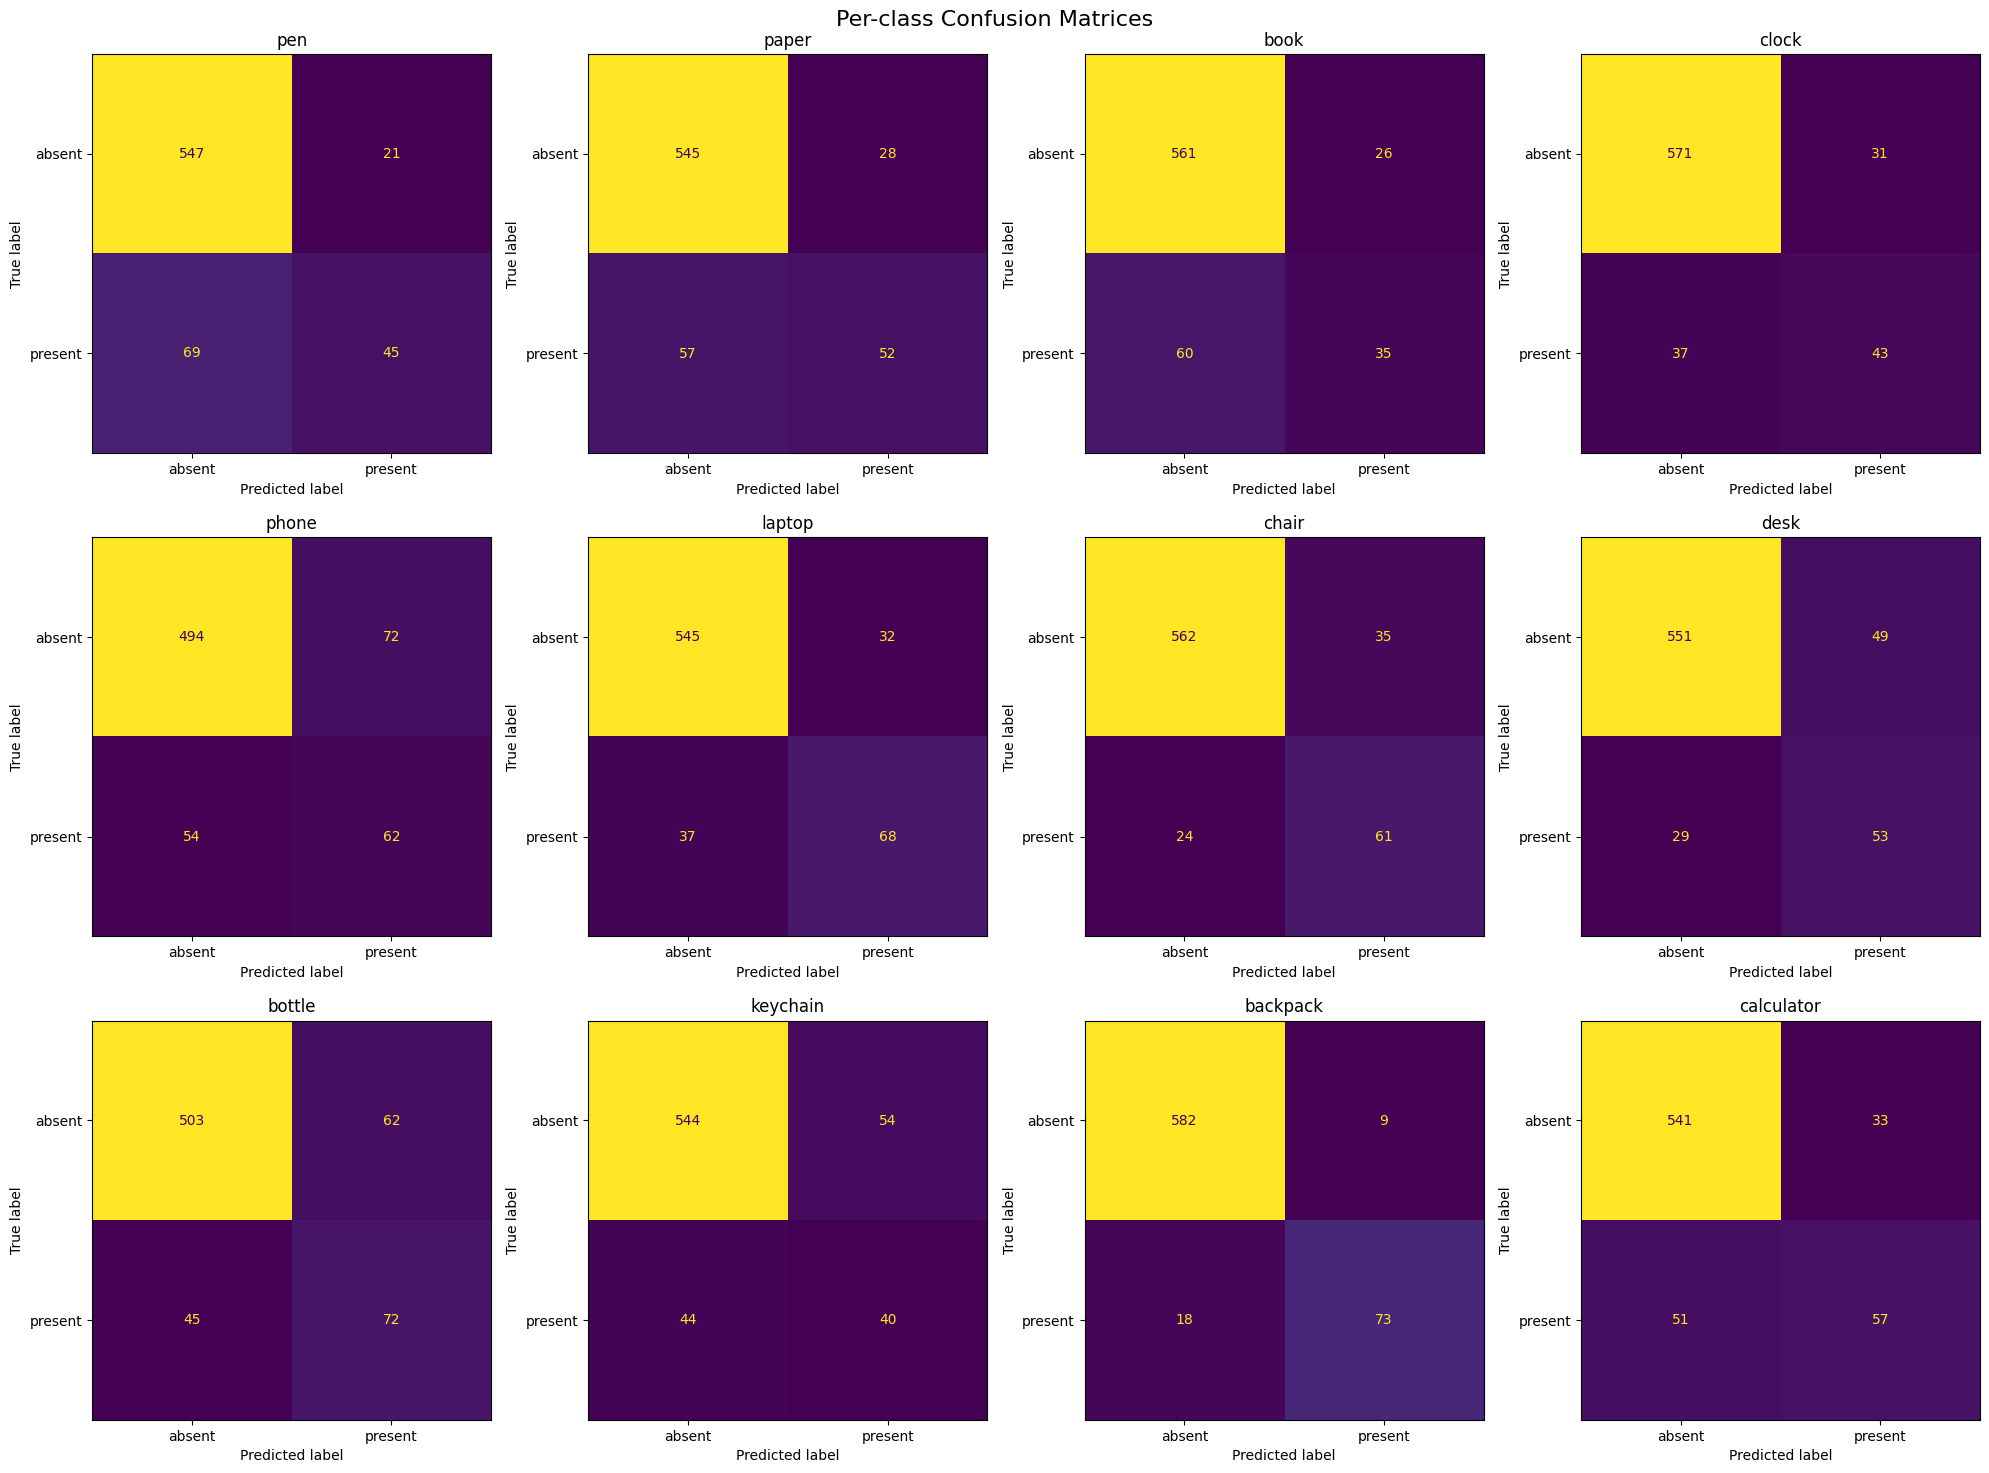

In [11]:
#@title Evaluating the Model

''' Evaluation '''
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, accuracy_score, f1_score
)

model.load_state_dict(torch.load('best_model.pth'))
model.to(device)
model.eval()

all_labels   = []
all_predicts = []
all_probs    = []
test_loss    = 0.0

with torch.no_grad():
    for X, y in test_loader:
        X, y   = X.to(device), y.to(device)
        outputs = model(X)
        loss    = criterion(outputs, y)
        test_loss += loss.item() * X.size(0)
        probs  = torch.sigmoid(outputs)
        preds  = (probs > THRESHOLD).float()
        all_labels.extend(y.cpu().numpy().tolist())
        all_predicts.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())

test_loss /= len(test_dataset)

all_labels   = np.array(all_labels)
all_predicts = np.array(all_predicts)
all_probs    = np.array(all_probs)



print('Loss:', test_loss)
print('\n--- Per-class report (each of the 12 labels treated as independent binary) ---')
print(classification_report(all_labels, all_predicts, target_names=CLASS_NAMES, digits=4, zero_division=0))

print('\n--- Aggregated metrics ---')
for avg in ('macro', 'micro', 'samples', 'weighted'):
    p = precision_score(all_labels, all_predicts, average=avg, zero_division=0)
    r = recall_score(all_labels,    all_predicts, average=avg, zero_division=0)
    f = f1_score(all_labels,        all_predicts, average=avg, zero_division=0)
    print(f'  [{avg:9s}]  Precision={p:.4f}  Recall={r:.4f}  F1={f:.4f}')

subset_acc = accuracy_score(all_labels, all_predicts)
print(f'\nSubset (exact-match) Accuracy: {subset_acc:.4f}')

hamming_acc = (all_labels == all_predicts).mean()
print(f'Hamming Accuracy (element-wise): {hamming_acc:.4f}')

print('\n--- Per-class confusion matrices ---')
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()
for i, cls in enumerate(CLASS_NAMES):
    cm = confusion_matrix(all_labels[:, i], all_predicts[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['absent', 'present'])
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(cls)
plt.suptitle('Per-class Confusion Matrices', fontsize=16)
plt.tight_layout()
plt.show()

In [12]:
#@title ROC-AUC Curves

import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_multilabel(labels, probs, class_names, caption='ROC Curves (per class)'):
    """
    labels : (N, C) binary ground-truth matrix
    probs  : (N, C) sigmoid probability matrix
    """
    plt.figure(figsize=(14, 8))
    for i, cls in enumerate(class_names):
        if labels[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(labels[:, i], probs[:, i])
        roc_auc     = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{cls} (AUC={roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(caption)
    plt.legend(loc='lower right', bbox_to_anchor=(1.35, 0.0))
    plt.tight_layout()
    plt.savefig('roc_multilabel.png', dpi=300)
    plt.show()


def predicting(ensemble_prob, threshold=0.5):
    """Convert probability matrix to binary predictions."""
    return (ensemble_prob > threshold).astype(float)


def metrics(labels, predictions, class_names):
    from sklearn.metrics import (
        classification_report, confusion_matrix, ConfusionMatrixDisplay,
        balanced_accuracy_score
    )
    print('Classification Report (multi-label, per class):')
    print('Labels      shape:', labels.shape)
    print('Predictions shape:', predictions.shape)
    print(classification_report(labels, predictions, target_names=class_names, digits=4, zero_division=0))


    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()
    classwise_bal_acc = []
    for i, cls in enumerate(class_names):
        cm = confusion_matrix(labels[:, i], predictions[:, i])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['absent', 'present'])
        disp.plot(ax=axes[i], colorbar=False)
        axes[i].set_title(cls)
        axes[i].tick_params(axis='x', rotation=0)
        if labels[:, i].sum() > 0:
            classwise_bal_acc.append(balanced_accuracy_score(labels[:, i], predictions[:, i]))
    plt.suptitle('Per-class Confusion Matrices', fontsize=16)
    plt.tight_layout()
    plt.show()

    print('\nClasswise Balanced Accuracy:', classwise_bal_acc)
    print('\nMean Balanced Accuracy:', np.mean(classwise_bal_acc))

    cooccurrence = np.zeros((len(class_names), len(class_names)))
    for true_row, pred_row in zip(labels, predictions):
        true_indices = np.where(true_row == 1)[0]
        pred_indices = np.where(pred_row == 1)[0]
        for i in true_indices:
            for j in pred_indices:
                cooccurrence[i, j] += 1

    fig, ax = plt.subplots(figsize=(14, 11))
    im = ax.imshow(cooccurrence, cmap='Blues')
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Label Co-occurrence Matrix\n(row = true class, col = predicted class)')
    plt.colorbar(im, ax=ax)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, int(cooccurrence[i, j]), ha='center', va='center', fontsize=8,
                    color='white' if cooccurrence[i, j] > cooccurrence.max() * 0.6 else 'black')
    plt.tight_layout()
    plt.savefig('cooccurrence_matrix.png', dpi=300)
    plt.show()

For Model MobileNetV2 (Multi-Label):
Classification Report (multi-label, per class):
Labels      shape: (682, 12)
Predictions shape: (682, 12)
              precision    recall  f1-score   support

         pen     0.6818    0.3947    0.5000       114
       paper     0.6500    0.4771    0.5503       109
        book     0.5738    0.3684    0.4487        95
       clock     0.5811    0.5375    0.5584        80
       phone     0.4627    0.5345    0.4960       116
      laptop     0.6800    0.6476    0.6634       105
       chair     0.6354    0.7176    0.6740        85
        desk     0.5196    0.6463    0.5761        82
      bottle     0.5373    0.6154    0.5737       117
    keychain     0.4255    0.4762    0.4494        84
    backpack     0.8902    0.8022    0.8439        91
  calculator     0.6333    0.5278    0.5758       108

   micro avg     0.5939    0.5573    0.5750      1186
   macro avg     0.6059    0.5621    0.5758      1186
weighted avg     0.6065    0.5573    0.5732  

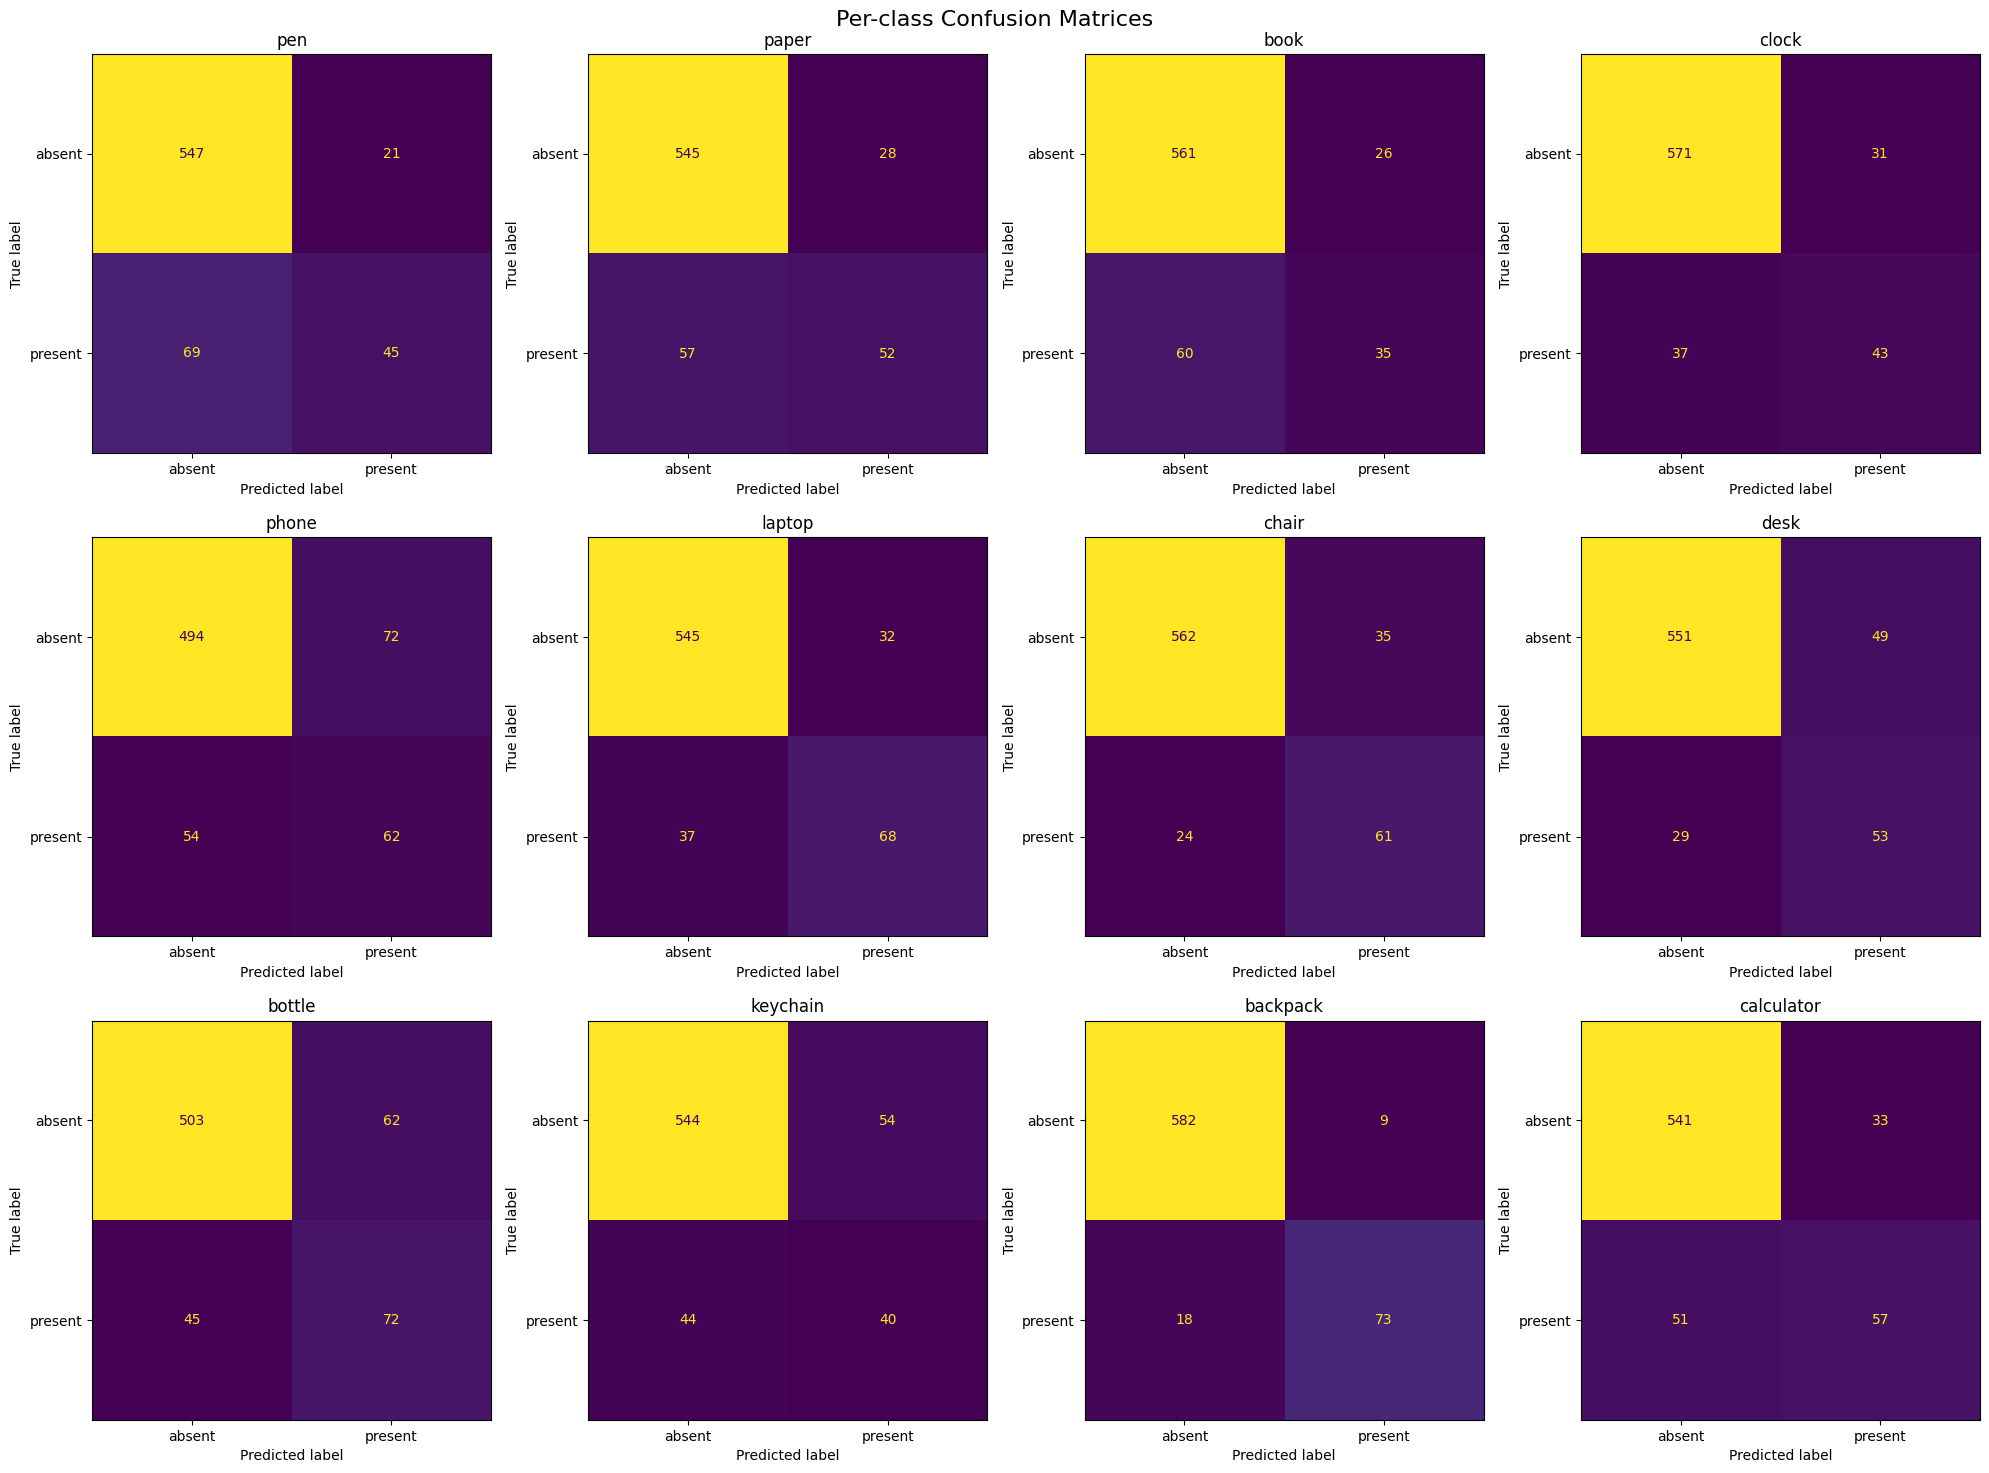


Classwise Balanced Accuracy: [np.float64(0.6788825055596739), np.float64(0.7140993003186192), np.float64(0.6620640186496907), np.float64(0.7430024916943522), np.float64(0.7036371390276592), np.float64(0.7960798877609969), np.float64(0.829510296580944), np.float64(0.7823373983739838), np.float64(0.7528250510551395), np.float64(0.6929447364229973), np.float64(0.8934846879009315), np.float64(0.7351432442895858)]

Mean Balanced Accuracy: 0.7486675631362146


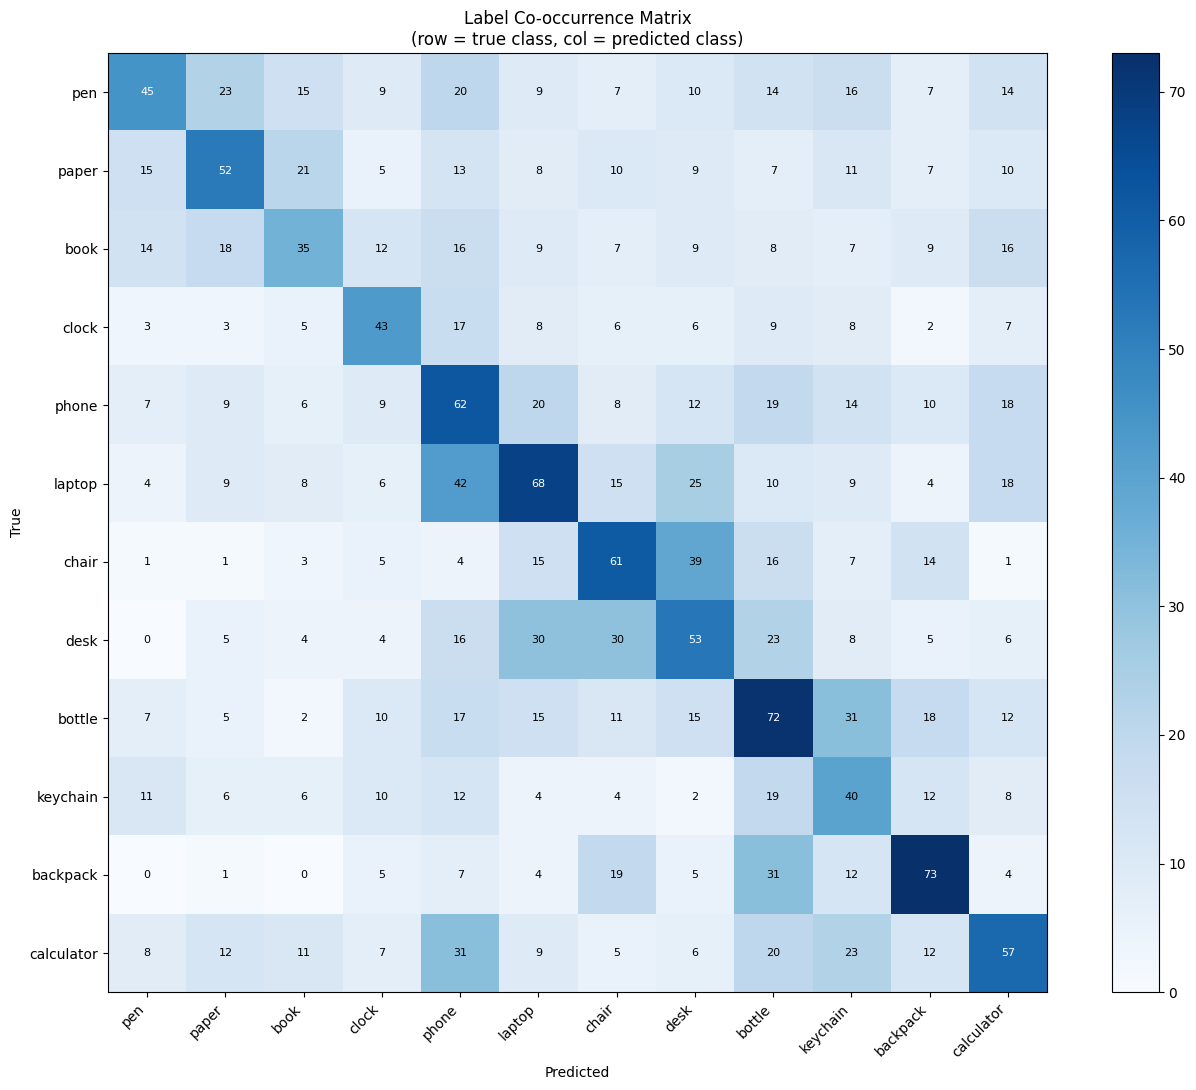

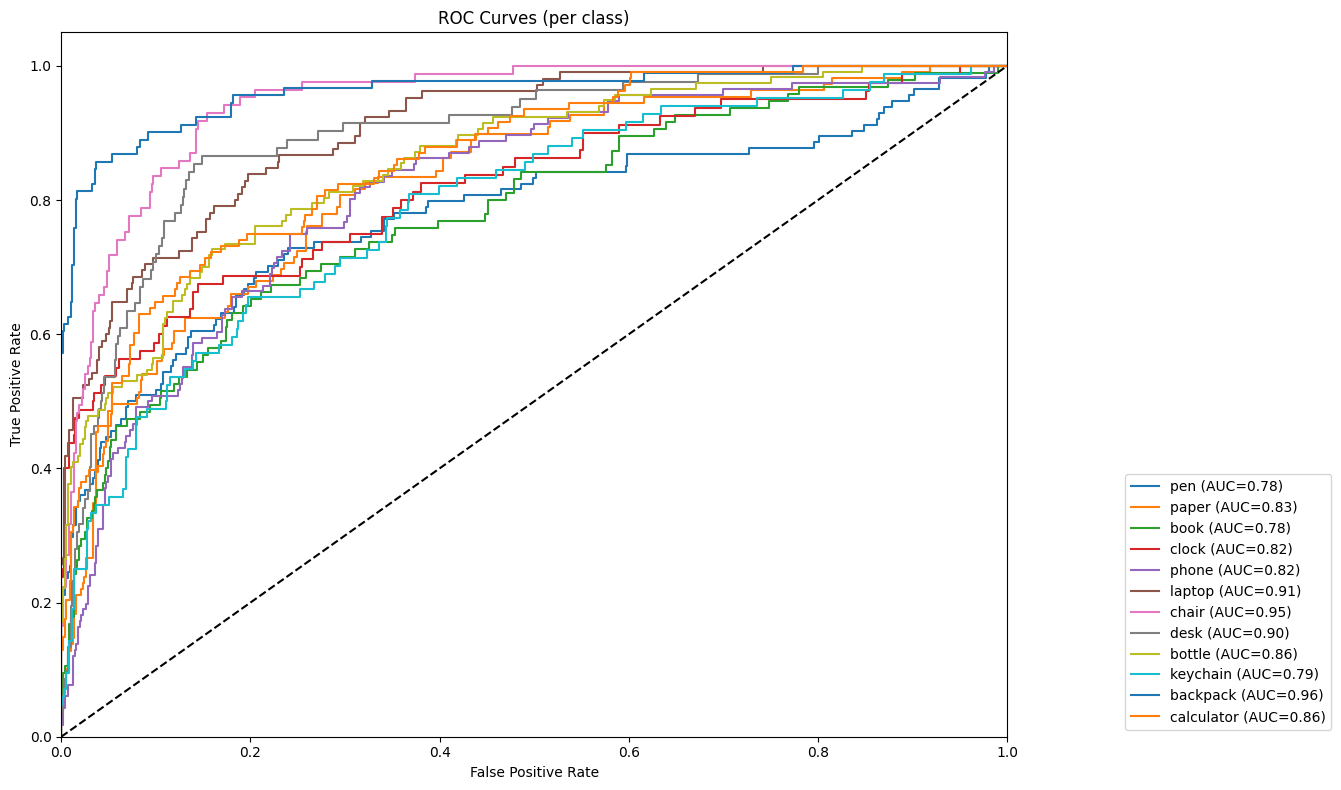

Accuracy[0.2507] Precision[0.6059] Recall[0.5621] F1[0.5758]
________________________________________________________________


Overall Accuracy[0.2507] Overall Precision[0.6059] Overall Recall[0.5621] Overall F1[0.5758]


In [13]:
#@title Testing the Model

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('For Model MobileNetV2 (Multi-Label):')


metrics(all_labels, all_predicts, CLASS_NAMES)
plot_roc_multilabel(all_labels, all_probs, CLASS_NAMES)

avg_acc_list       = []
avg_precision_list = []
avg_recall_list    = []
avg_f1_list        = []


acc_fold       = accuracy_score(all_labels, all_predicts)
precision_fold = precision_score(all_labels, all_predicts, average='macro', zero_division=0)
recall_fold    = recall_score(all_labels,    all_predicts, average='macro', zero_division=0)
f1_fold        = f1_score(all_labels,        all_predicts, average='macro', zero_division=0)

avg_acc_list.append(acc_fold)
avg_precision_list.append(precision_fold)
avg_recall_list.append(recall_fold)
avg_f1_list.append(f1_fold)

print('Accuracy[{:.4f}] Precision[{:.4f}] Recall[{:.4f}] F1[{:.4f}]'.format(
    acc_fold, precision_fold, recall_fold, f1_fold))
print('________________________________________________________________')

avg_acc    = np.asarray(avg_acc_list)
avg_pre    = np.asarray(avg_precision_list)
avg_recall = np.asarray(avg_recall_list)
avg_f1     = np.asarray(avg_f1_list)
print('\n')
print('Overall Accuracy[{:.4f}] Overall Precision[{:.4f}] Overall Recall[{:.4f}] Overall F1[{:.4f}]'.format(
    np.mean(avg_acc), np.mean(avg_pre), np.mean(avg_recall), np.mean(avg_f1)))

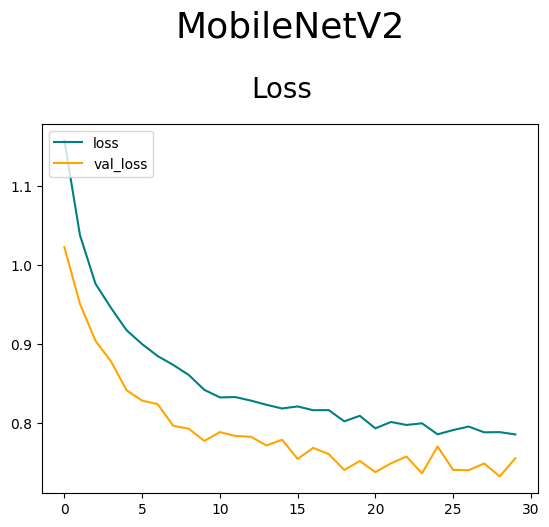

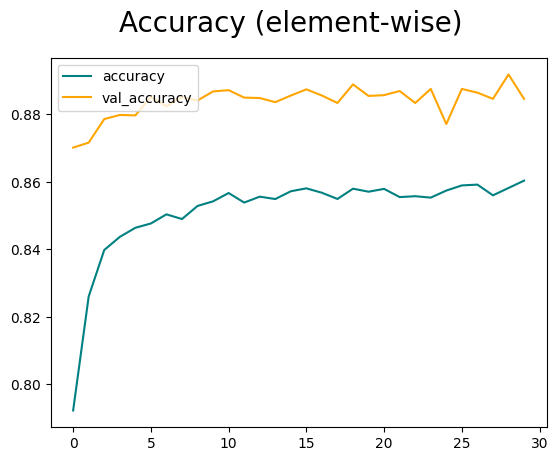

In [14]:
#@title Performance Graphs


import matplotlib.pyplot as plt

''' MobileNetV2 '''
fig = plt.figure()
plt.title('MobileNetV2\n\n', loc='center', fontsize=26)
plt.plot(hist['loss'],     color='teal',   label='loss')
plt.plot(hist['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc='upper left')
plt.show()

fig = plt.figure()
plt.plot(hist['accuracy'],     color='teal',   label='accuracy')
plt.plot(hist['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy (element-wise)', fontsize=20)
plt.legend(loc='upper left')
plt.show()

In [15]:
# @title Saving the Models

save_path = os.path.join('/content/drive/My Drive/FinalProject/model', 'mobilenetv2_multilabel.pth')
torch.save(model.state_dict(), save_path)
print(f'Model saved to {save_path}')


Model saved to /content/drive/My Drive/FinalProject/model/mobilenetv2_multilabel.pth
